In [117]:
import geopandas as gpd
from geodatasets import get_path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from shapely.geometry import Point

import pandas as pd
import numpy as np

import glob
import os
from shapely import wkt
import geopandas as gpd

In [118]:
# load all extracted dataframes
education = pd.read_csv("./output/education.csv")
income = pd.read_csv("./output/income.csv")
pops = pd.read_csv("./output/pops.csv")
racial = pd.read_csv("./output/racial.csv")
tenure = pd.read_csv("./output/tenure.csv")

# merge all dataframes into one
df = pd.merge(education, income, on="ZIP Code")
df = pd.merge(df, pops, on="ZIP Code")
df = pd.merge(df, racial, on="ZIP Code")
df = pd.merge(df, tenure, on="ZIP Code")

# drop unnecessary columns
df.drop(columns=["pop_est_old", 'geometry_y', 'geometry_x'], inplace=True)

# rename columns
columns_rename = {
    'S1501_C02_002E': 'less than highschool graduate',
    'S1501_C02_003E': 'high school graduate',
    'S1501_C02_004E':'some college or associate degree',
    'S1501_C02_005E':'bachelor\'s degree or higher',
    'S1901_C02_012E':'Median Household Income',
    'S1901_C02_013E':'Mean Household Income',
}

df.columns

Index(['ZIP Code', 'S1501_C02_002E', 'S1501_C02_003E', 'S1501_C02_004E',
       'S1501_C02_005E', 'S1901_C02_012E', 'S1901_C02_013E', 'SAFMR 1BR_old',
       'SAFMR 1BR_new', 'SAFMR_1BR_change', 'SAFMR_1BR_PERC_CHANGE',
       'pops_count', 'pop_est', 'geometry', 'SAFMR 1BR', 'change_perc_asian',
       'change_perc_black', 'change_perc_white', 'perc_white', 'perc_black',
       'perc_asian', '1989_percentage'],
      dtype='object')

In [119]:
# Convert the 'geometry' column from WKT text to real shapely objects
df['geometry'] = df['geometry'].apply(wkt.loads)

# Now make it a GeoDataFrame
df = gpd.GeoDataFrame(df, geometry='geometry')

# (Optional but good practice) Set the CRS
df = df.set_crs(epsg=4326)  # WGS84 latitude/longitude

In [120]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import numpy as np

income_max = df['S1901_C02_012E'].max()

# Define the calculation function
def calculate_gentrification_index(row, weight_a, weight_b):
    a = row['perc_white'] / 100
    # percentage of adults w college or higher degree
    b = row['S1501_C02_005E'] / 100
    # mean income
    c = row['S1901_C02_012E']
    c = c / income_max
   
    weight_c = 1 - weight_a - weight_b
    return weight_a * a + weight_b * b + weight_c * c

# Update function
def update_plot(weight_a, weight_b):
    weight_c = 1 - weight_a - weight_b
    weight_c = max(0, weight_c)  # Clamp to 0 if invalid

    if weight_c < 0:
        output.clear_output()
        with output:
            print("Invalid weights: a + b must be ≤ 1")
        return

    df['gentrification_index'] = df.apply(
        lambda row: calculate_gentrification_index(row, weight_a, weight_b),
        axis=1
    )
    # Normalize
    df['gentrification_index'] = (
        df['gentrification_index'] - df['gentrification_index'].min()
    ) / (df['gentrification_index'].max() - df['gentrification_index'].min())

    # Plot
    output.clear_output()
    with output:
        cmap = plt.cm.viridis
        ax = df.plot(
            column='gentrification_index',
            cmap=cmap,
            legend=True,
            legend_kwds={'label': "Gentrification Index", 'orientation': "vertical"},
            figsize=(8, 6)
        )
        plt.title(f"Weight A: {weight_a:.2f}, B: {weight_b:.2f}, C: {weight_c:.2f}")
        plt.show()
        c_slider.value = weight_c  # Update visual of c

# Sliders
a_slider = widgets.FloatSlider(value=0.2, min=0.0, max=1.0, step=0.01, description='Weight A')
b_slider = widgets.FloatSlider(value=0.35, min=0.0, max=1.0, step=0.01, description='Weight B')
c_slider = widgets.FloatSlider(value=0.45, min=0.0, max=1.0, step=0.01, description='Weight C', disabled=True)

# Output area
output = widgets.Output()

# Interactivity
def on_slider_change(change):
    update_plot(a_slider.value, b_slider.value)

a_slider.observe(on_slider_change, names='value')
b_slider.observe(on_slider_change, names='value')

# Display
display(widgets.VBox([a_slider, b_slider, c_slider]), output)

# Initial draw
update_plot(a_slider.value, b_slider.value)

Output()

In [121]:
correlation_df = df.copy()

In [122]:
import pandas as pd
from scipy.stats import pearsonr, ttest_ind

# Ensure relevant columns are numeric and drop rows with NaNs
relevant_cols = [
    'pops_count', 'gentrification_index', 'perc_white', 'perc_black',
    'perc_asian', 'S1501_C02_005E', 'S1901_C02_013E', '1989_percentage'
]
correlation_df = correlation_df[relevant_cols].dropna()
# 1. Pearson correlation between pops_count and other numerical variables
correlation_results = {}
for col in relevant_cols:
    if col != 'pops_count':
        corr, pval = pearsonr(correlation_df['pops_count'], correlation_df[col])
        correlation_results[col] = {'correlation': corr, 'p_value': pval}
# 2. Two-sample t-test for pops_count based on gentrification_index (median split)
median_gi = correlation_df['gentrification_index'].median()
group_high = correlation_df[correlation_df['gentrification_index'] > median_gi]['pops_count']
group_low = correlation_df[correlation_df['gentrification_index'] <= median_gi]['pops_count']
t_stat, t_pval = ttest_ind(group_high, group_low)

correlation_results, (t_stat, t_pval)

({'gentrification_index': {'correlation': 0.5602545572776433,
   'p_value': 0.000170257722736483},
  'perc_white': {'correlation': 0.41284835580655105,
   'p_value': 0.008107875376961485},
  'perc_black': {'correlation': -0.36043256847052374,
   'p_value': 0.022331260824712592},
  'perc_asian': {'correlation': 0.31491923318350296,
   'p_value': 0.04778799972335393},
  'S1501_C02_005E': {'correlation': 0.5408666794458689,
   'p_value': 0.00031420692917288114},
  'S1901_C02_013E': {'correlation': 0.32645443653800876,
   'p_value': 0.039790800946888305},
  '1989_percentage': {'correlation': -0.36685155842570477,
   'p_value': 0.019888930690790656}},
 (3.67392910955571, 0.0007332329391029054))

In [123]:
from scipy.stats import ttest_ind

# Split the data based on the median of the gentrification index
median_gi = correlation_df['gentrification_index'].median()

# Group 1: High gentrification index
group_high = correlation_df[correlation_df['gentrification_index'] > median_gi]['pops_count']

# Group 2: Low gentrification index
group_low = correlation_df[correlation_df['gentrification_index'] <= median_gi]['pops_count']

# Perform a two-sample t-test (assuming equal variances; use `equal_var=False` to Welch's test)
t_stat, p_val = ttest_ind(group_high, group_low)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("Result: Significant difference in pops_count between high and low gentrification areas.")
else:
    print("Result: No significant difference in pops_count between groups.")


T-statistic: 3.6739
P-value: 0.0007
Result: Significant difference in pops_count between high and low gentrification areas.


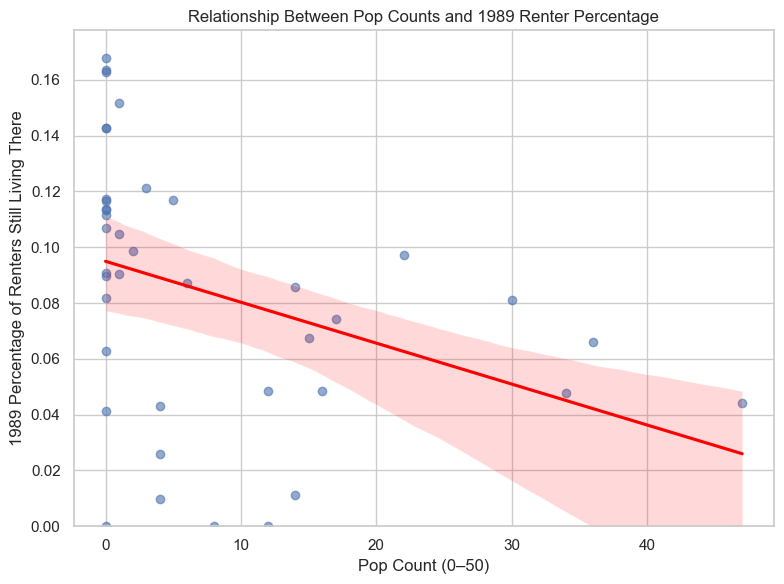

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the plot style
sns.set(style="whitegrid")

# Create the scatter plot with regression line (flipped axes)
plt.figure(figsize=(8, 6))
sns.regplot(
    x='pops_count',
    y='1989_percentage',
    data=correlation_df,
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)

plt.title('Relationship Between Pop Counts and 1989 Renter Percentage')
plt.xlabel('Pop Count (0–50)')
plt.ylabel('1989 Percentage of Renters Still Living There')
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()


In [125]:
df.to_csv("./output/gentrification_index.csv", index=False)